# Sub-agents, Teams and the Discipline

Welcome to the fourth and last notebook of the Harness Engineering module. In notebook 01 you learned that an agent is a model plus a harness. In notebook 02 you took the harness apart: models, context, tools and skills. In notebook 03 you built one, the `harness` package that sits next to this notebook: the loop, its guardrails, the five workflow patterns and an eval suite that measured three configurations of the same agent. Today the question changes from *how do I build one agent* to *when do I need more than one*, and then to the question the whole module has been building towards: what does it mean to do this as a discipline?

In plain words: one driver can take one car anywhere, but a convoy needs a lead car, a shared route and a way to talk. This notebook builds the convoy (sub-agents), the team of drivers sharing one job board (agent teams), and the moment one driver hands the wheel to another (handoffs). Then it shows the ways convoys crash, and ends with the checklist harness engineers actually use.

Every agent below is real: `claude-opus-5` leads, `claude-sonnet-5` does the reading, and every number printed comes from the `usage` object the API returned in the run recorded here. The agents read files of this very repository, so every answer can be checked by opening the file it names.

**What you will learn**

- Why splitting the context across agents helps, measured on real token counts, with the numbers from Anthropic's multi-agent research system (13 Jun 2025).
- The difference between an orchestrator that is code and a lead agent that decides to delegate, on the same question.
- How a flat agent team shares a task board, how much faster it is, and how that differs from hierarchical sub-agents.
- What a handoff is, how it differs from delegation, and what the inherited conversation costs.
- The known failure modes: runaway loops, context pollution and cost multiplication, each provoked for real and stopped by the harness.
- The discipline: instruction files, executable guards, evals in CI, observability and permission design.

**Sources used in this notebook**: Anthropic, "How we built our multi-agent research system" (13 Jun 2025); Anthropic, "Effective context engineering for AI agents" (29 Sep 2025); OpenAI, "A practical guide to building agents" (Apr 2025); Anthropic, Claude Code documentation on subagents and agent teams (2025 to 2026); OpenAI, "Harness engineering" (11 Feb 2026); Marmelab, "The State of AI Harness Engineering 2026" (24 Sep 2026).

## How to run this notebook

- **Locally (Jupyter, JupyterLab, VS Code):** open this file from the `M5 - Harness Engineering` folder and run the cells top to bottom. The `harness` package sits next to the notebook.
- **Google Colab:** upload the file and run the cells top to bottom. The setup cell downloads the package and a short list of repository files for the agents to read.

**You need an Anthropic API key.** Locally, copy `.env.example` at the repository root to `.env` and fill in `ANTHROPIC_API_KEY=...`; the file is git-ignored and the package's `load_client()` is the only code that reads it. On Colab, add a secret called `ANTHROPIC_API_KEY` in the Secrets panel. Never paste a key into a cell: the repository's checks reject any notebook that contains one.

Real runs **cost money and vary**. A full run of this notebook costs well under one US dollar (0.44 USD in the run recorded here); the last cell prints the exact bill. Two runs of the same cell can differ in wording, in the route the model takes and, in the team section, in which teammate takes which task. The prose says "in the run recorded here" wherever it quotes a result.

In [1]:
# SETUP - run this cell first. It finds the harness package (or downloads it on Colab), loads the key and creates the client.
import importlib.util
import pathlib
import subprocess
import sys
import urllib.parse
import urllib.request


def ensure(package, pip_name=None):
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or package])


ensure("anthropic")
ensure("dotenv", "python-dotenv")
ensure("yaml", "pyyaml")
ensure("pydantic")

MODULE = pathlib.Path.cwd()
try:
    import google.colab  # noqa: F401
    ON_COLAB = True
except ImportError:
    ON_COLAB = False
if not (MODULE / "harness" / "__init__.py").exists():        # Colab: fetch the package and the files the tools read
    RAW = "https://raw.githubusercontent.com/maglionejm/fontys-tech-exercises/main/"
    PACKAGE_FILES = ["harness/__init__.py", "harness/__main__.py", "harness/cli.py", "harness/client.py",
                     "harness/evals.py", "harness/hooks.py", "harness/loop.py", "harness/repo_tools.py",
                     "harness/tools.py", "harness/trace.py", "evals/cases.yaml"]
    REPO_FILES = ["README.md", "LICENSE", "CHANGELOG.md", "CONTRIBUTING.md", "requirements.txt", "requirements-dev.txt",
                  ".github/workflows/notebooks.yml", ".github/workflows/ci.yml", "docs/data/model.json",
                  "M1 - Descriptive analytics/README.md", "M2 - Machine Learning/README.md",
                  "M3 - ML Architectures and Deployment/README.md", "M5 - Harness Engineering/README.md"]

    def download(url, target):
        target.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(url, target)

    for rel in PACKAGE_FILES:
        download(RAW + urllib.parse.quote("M5 - Harness Engineering/" + rel), MODULE / rel)
    for rel in REPO_FILES:
        download(RAW + urllib.parse.quote(rel), MODULE / "repo" / rel)

sys.path.insert(0, str(MODULE))
from harness import (Agent, Hooks, tool, load_client, MissingKeyError, MAIN_MODEL, WORKER_MODEL,
                     list_files, read_file, repo_root, set_repo_root, load_cases)

if ON_COLAB:
    set_repo_root(MODULE / "repo")                          # the tools read the downloaded copy

try:
    client = load_client()                                  # the only code that reads the key
except MissingKeyError as exc:
    raise SystemExit(str(exc))

print(f"Client ready. Lead model: {MAIN_MODEL} | worker model: {WORKER_MODEL}")
print(f"The agents read the repository rooted at the folder named {repo_root().name!r}.")

Client ready. Lead model: claude-opus-5 | worker model: claude-sonnet-5
The agents read the repository rooted at the folder named 'fontys-tech-exercises'.


### Setup, part 2: shared helpers

Three small helpers are used throughout: `make_worker()` builds the research agent of notebook 03 on the worker model; `record()` keeps a ledger of every run so the last section can add up the bill; `barh()` draws the horizontal bar charts. `parts_answered()` checks which of the three facts of our compound question an answer contains, so we can grade answers without reading them by eye.

In [2]:
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

WORKER_SYSTEM = (
    "You answer one question about the code repository you are running in. Look things up with "
    "list_files and read_file before answering; never guess. Answer in two or three sentences and "
    "name the repository-relative path of every file you used. If the repository does not contain "
    "the answer, say so."
)


def make_worker(name="worker", **overrides):
    """The research agent of notebook 03, on the cheaper worker model with low effort."""
    settings = dict(model=WORKER_MODEL, system=WORKER_SYSTEM, tools=[list_files, read_file],
                    effort="low", max_turns=6, max_tokens=1500, name=name)
    settings.update(overrides)
    return Agent(client, **settings)


LEDGER = []                                        # every run of this notebook, for the bill at the end


def record(architecture, runs, answered=None):
    """Add the runs of one experiment to the ledger and print their totals."""
    runs = list(runs)
    usage = sum((r.usage for r in runs), start=type(runs[0].usage)())
    row = {"architecture": architecture, "runs": len(runs),
           "model calls": sum(r.turns for r in runs),
           "tool calls": sum(len(r.trace.of_kind("tool")) for r in runs),
           "input tokens": usage.total_input, "output tokens": usage.output_tokens,
           "cost_usd": round(sum(r.cost_usd for r in runs), 4),
           "seconds": round(sum(r.seconds for r in runs), 1), "questions answered": answered}
    LEDGER.append(row)
    print(f"[{architecture}] {row['model calls']} model calls, {row['tool calls']} tool calls, "
          f"{row['input tokens']:,} input tokens, {row['output tokens']:,} output tokens, "
          f"{row['cost_usd']:.4f} USD, {row['seconds']} s")


def barh(labels, values, title, xlabel, fmt="{:,.0f}"):
    fig, ax = plt.subplots(figsize=(8, 0.6 * len(labels) + 1.2))
    bars = ax.barh(labels, values, color="#4878a8")
    ax.invert_yaxis()
    ax.set_xlim(0, max(values) * 1.25)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    for bar, v in zip(bars, values):
        ax.text(v + max(values) * 0.01, bar.get_y() + bar.get_height() / 2, fmt.format(v), va="center")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


PARTS = {                                          # the three facts of the compound question, and the strings that prove them
    "part 1: the workflow (Python 3.12, actions v7)": ["3.12", "v7"],
    "part 2: the M3-only packages": ["fastapi", "uvicorn", "httpx", "requests"],
    "part 3: the model metrics": ["0.838", "0.779", "0.878"],
}


def parts_answered(text):
    text = text.lower()
    return {part: all(key.lower() in text for key in keys) for part, keys in PARTS.items()}


print("helpers ready")

helpers ready


## 1. Why split the context

Concrete anchor. A project lead who insists on reading every document the team reads is slower than the team, and worse at leading, because the details crowd out the overview. The same is true of an agent. The context window is a finite budget (notebook 02), and an agent that researches three questions in one context carries every file it read into every later step.

Anthropic's "Effective context engineering for AI agents" (29 Sep 2025) names the remedy: **sub-agent architectures**. A **sub-agent** is a fresh agent with a clean context, one focused task and a short report back. It may spend tens of thousands of tokens exploring and returns a summary of **1,000 to 2,000 tokens** to the lead. The lead keeps the summaries, not the exploration.

The production case is Anthropic's multi-agent research system (13 Jun 2025). A lead agent plans and spawns three to five sub-agents in parallel, each with its own context window and tools; a separate pass adds citations. On an internal research evaluation the system beat a single-agent setup by **90.2 percent**, at roughly **15 times the tokens** of a normal chat. The post's two lessons are the ones this notebook keeps returning to: **teach the orchestrator how to delegate** (clear task descriptions, boundaries, output format), and **scale effort to the complexity of the query**.

In plain words: a sub-agent is a tool whose implementation happens to be another agent. That is exactly how we build it. `delegate` is an ordinary `@tool`: when the lead calls it, the function starts a fresh worker `Agent` on the worker model, runs the whole loop of notebook 03, and returns only the worker's answer as the tool result. The lead (on `claude-opus-5`) has no `read_file`; the only way it can learn anything is to delegate.

The question is compound on purpose: three facts, three different files.

In [3]:
COMPOUND = (
    "Answer these three questions about this repository and name the file behind each answer. "
    "(1) Which Python version does the 'Execute notebooks' GitHub Actions workflow install, and which "
    "versions of actions/checkout and actions/setup-python does it use? "
    "(2) Which packages does requirements.txt say are only needed for the M3 notebooks 2 and 3? "
    "(3) What test accuracy, test F1 and test AUC does docs/data/model.json report?"
)

workers = []                                       # (agent, result) for every worker the lead starts, in order


@tool(risk="read")
def delegate(task: str) -> str:
    """Start a fresh research worker on one focused sub-question and return its written report.

    The worker has its own context and its own file-reading tools; you do not see what it reads.
    Call it once per sub-question.

    task: one self-contained question, naming the file to look in when you know it
    """
    worker = make_worker(name=f"worker-{len(workers) + 1}")
    result = worker.run(task)
    workers.append((worker, result))
    return result.answer


LEAD_SYSTEM = (
    "You coordinate research about a code repository. You cannot read files yourself. Split a compound "
    "question into focused sub-questions and call delegate once per sub-question; when the parts are "
    "independent, make all the delegate calls in the same turn. Then combine the reports into one answer "
    "that keeps every file path the workers named. Never answer from memory."
)

lead = Agent(client, model=MAIN_MODEL, system=LEAD_SYSTEM, tools=[delegate], effort="medium",
             max_turns=6, name="lead")
lead_run = lead.run(COMPOUND)

print(lead_run.answer)
print()
lead_run.trace.show()

**1) Execute notebooks workflow** — file: `.github/workflows/notebooks.yml`
- Python **3.12**
- `actions/checkout@v7`
- `actions/setup-python@v7`

**2) M3 notebooks 2 and 3 only** — file: `requirements.txt`
```
# Prediction APIs (only needed for M3 notebooks 2 and 3)
fastapi
uvicorn
httpx
requests
```

**3) Model metrics** — file: `docs/data/model.json`
- `"test_accuracy": 0.838`
- `"test_f1": 0.779`
- `"test_auc": 0.878`

turn  kind      name                    in/out tokens      s  detail
   1  model     claude-opus-5                 678/336    4.2  stop=tool_use I'll dispatch three workers, one per question.
   1  tool      delegate                                 3.8  {'task': 'In this repository, find th... -> The workflow is **`.github/workflows/notebo...
   1  tool      delegate                                 3.2  {'task': 'Look at requirements.txt in... -> According to **requirements.txt**, the pack...
   1  tool      delegate                                 2.3  {'task': 'Ope

Read the trace from the bottom up. Every `tool` line is one `delegate` call; between the lead's model calls, a whole worker ran (its own model calls and file reads are not in this trace, because they happened in another context). Now measure where the reading happened. `count_tokens` asks the API how many tokens each agent's final message list holds: that is the size of the context each agent was carrying when it stopped.

In [4]:
lead_context = lead.count_tokens(lead_run.messages)
worker_contexts = [agent.count_tokens(result.messages) for agent, result in workers]

print(f"Lead: {lead_run.turns} model calls, final context {lead_context:,} tokens, "
      f"stopped because {lead_run.stopped_because!r}, {lead_run.cost_usd:.4f} USD")
print(f"Workers started: {len(workers)}")
for (agent, result), size in zip(workers, worker_contexts):
    print(f"   {agent.name}: {result.turns} model calls, {len(result.trace.of_kind('tool'))} tool calls, "
          f"final context {size:,} tokens, {result.cost_usd:.4f} USD -> {result.answer[:70]!r}")
lead_parts = parts_answered(lead_run.answer)
print("Parts of the question answered by the lead:", sum(lead_parts.values()), "of", len(PARTS))
record("Lead + workers", [lead_run] + [r for _, r in workers], answered=sum(lead_parts.values()))

Lead: 2 model calls, final context 1,527 tokens, stopped because 'done', 0.0238 USD
Workers started: 3
   worker-1: 3 model calls, 2 tool calls, final context 2,230 tokens, 0.0094 USD -> 'The workflow is **`.github/workflows/notebooks.yml`**. It installs Pyt'
   worker-2: 2 model calls, 1 tool calls, final context 1,137 tokens, 0.0050 USD -> 'According to **requirements.txt**, the packages marked as only needed '
   worker-3: 2 model calls, 1 tool calls, final context 1,799 tokens, 0.0061 USD -> 'In `docs/data/model.json`, the reported metrics are: `"test_accuracy":'
Parts of the question answered by the lead: 3 of 3
[Lead + workers] 9 model calls, 7 tool calls, 10,081 input tokens, 995 output tokens, 0.0444 USD, 25.8 s


Compare that with a single agent on the strong model, given the same compound question and the file-reading tools directly. It has to carry every file it reads in its own context.

In [5]:
solo = Agent(client, model=MAIN_MODEL, system=WORKER_SYSTEM.replace("one question", "a question"),
             tools=[list_files, read_file], effort="medium", max_turns=10, name="solo")
solo_run = solo.run(COMPOUND)
solo_context = solo.count_tokens(solo_run.messages)

print(solo_run.answer)
print()
solo_run.trace.show()
solo_parts = parts_answered(solo_run.answer)
print(f"\nSolo: {solo_run.turns} model calls, {len(solo_run.trace.of_kind('tool'))} tool calls, "
      f"final context {solo_context:,} tokens, stopped because {solo_run.stopped_because!r}")
print("Parts of the question answered by the solo agent:", sum(solo_parts.values()), "of", len(PARTS))
record("Solo agent", [solo_run], answered=sum(solo_parts.values()))

1. The "Execute notebooks" workflow installs Python 3.12 and uses `actions/checkout@v7` and `actions/setup-python@v7` (in both the `execute` and `module-5` jobs) — `.github/workflows/notebooks.yml`.
2. The packages marked "only needed for M3 notebooks 2 and 3" are `fastapi`, `uvicorn`, `httpx` and `requests` — `requirements.txt`.
3. The saved model reports test accuracy 0.838, test F1 0.779 and test AUC 0.878 — `docs/data/model.json`.

turn  kind      name                    in/out tokens      s  detail
   1  model     claude-opus-5                 772/108    2.1  stop=tool_use I'll look up each of these.
   1  tool      list_files                               0.0  {'folder': '.'} -> .github/ docs/ M1 - Descriptive analytics/ M2 -...
   1  tool      list_files                               0.0  {'folder': '.github/workflows'} -> ci.yml harness.yml notebooks.yml pages.yml
   2  model     claude-opus-5                1144/160    2.2  stop=tool_use
   2  tool      read_file              

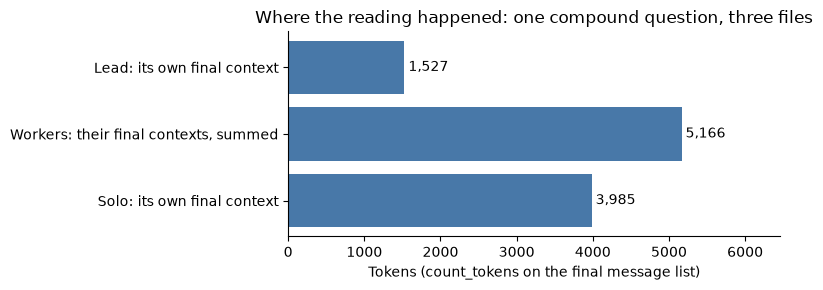

In [6]:
labels = ["Lead: its own final context", "Workers: their final contexts, summed", "Solo: its own final context"]
values = [lead_context, sum(worker_contexts), solo_context]
barh(labels, values, "Where the reading happened: one compound question, three files", "Tokens (count_tokens on the final message list)")

How to read it: the first and third bars are the size of an agent's own context when it finished, counted by the API on the exact messages it carried. The middle bar is the sum of the workers' final contexts, which the lead never saw. The lead's bar is the one to watch: it answered the whole question while carrying only the reports, not the files. In the run recorded here the lead finished with 1,527 tokens of context; its three workers finished with 2,230, 1,137 and 1,799 (5,166 together); the solo agent finished with 3,985, about two and a half times the lead. Both architectures answered all three parts. The work did not disappear; it moved into contexts that end when the worker ends.

That is the whole argument for isolation in one picture: the lead stays small and coherent, the exploration happens elsewhere, and the bill is the sum of both. Section 5 comes back to the bill, and to what the solo agent did with the three parts.

## 2. Orchestrator-workers versus sub-agents as tools

Notebook 03 ran the orchestrator-workers pattern: a planner produces subtasks, workers do them in parallel, a synthesizer combines. The lead agent in section 1 looks similar and is not. The difference is **who decides the shape of the work**.

- In the orchestrator, **the code decides**. The sequence is fixed: plan, then work, then combine. The model fills in the subtasks, and that is all it may do. This is a workflow.
- With the `delegate` tool, **the model decides**. Delegation is just a tool call. The lead may delegate three times, once, or not at all; it may read a report and delegate again; nothing in the harness forces the shape. This is an agent, and OpenAI's guide calls it the **manager pattern**: agents used as tools of a central manager (OpenAI, "A practical guide to building agents", Apr 2025).

Predictability against flexibility. The workflow version is easier to test and cheaper to reason about; the agent version handles the compound question you did not anticipate. Below, the same question goes through the orchestrator: a planner on the worker model with a structured output (a JSON schema with one list, `subtasks`), the same `make_worker()` for each subtask, this time in a thread pool so they run at the same time, and a synthesizer on the lead model.

In [7]:
from concurrent.futures import ThreadPoolExecutor

PLAN_SCHEMA = {
    "type": "object",
    "properties": {"subtasks": {"type": "array", "items": {"type": "string"},
                                "description": "Self-contained sub-questions, one per fact to look up."}},
    "required": ["subtasks"],
}
planner = Agent(client, model=WORKER_MODEL, effort="low", output_schema=PLAN_SCHEMA, name="planner",
                system="You split a compound question about a code repository into the smallest list of "
                       "self-contained sub-questions, one per fact to look up. Return only the JSON object.")
plan = planner.run(COMPOUND)
subtasks = plan.parsed["subtasks"]
print("Planner produced", len(subtasks), "subtasks:")
for i, task in enumerate(subtasks, start=1):
    print(f"   {i}. {task}")

started = time.perf_counter()
with ThreadPoolExecutor(max_workers=4) as pool:
    orc_workers = list(pool.map(lambda pair: (pair[0], pair[0].run(pair[1])),
                                [(make_worker(f"orc-worker-{i}"), task) for i, task in enumerate(subtasks, start=1)]))
worker_seconds = time.perf_counter() - started

reports = "\n\n".join(f"Report {i}: {result.answer}" for i, (_, result) in enumerate(orc_workers, start=1))
synthesizer = Agent(client, model=MAIN_MODEL, effort="medium", name="synthesizer",
                    system="Combine the worker reports into one answer to the question. Keep every file path "
                           "the reports name. Do not add facts of your own.")
synth_run = synthesizer.run(f"Question: {COMPOUND}\n\n{reports}")
print()
print(synth_run.answer)
orc_parts = parts_answered(synth_run.answer)
print("\nParts answered:", sum(orc_parts.values()), "of", len(PARTS),
      f"| workers ran in parallel in {worker_seconds:.1f} s")
record("Orchestrator-workers", [plan, synth_run] + [r for _, r in orc_workers], answered=sum(orc_parts.values()))

Planner produced 4 subtasks:
   1. Which Python version does the 'Execute notebooks' GitHub Actions workflow install, and in which file is this workflow defined?
   2. Which versions of actions/checkout and actions/setup-python does the 'Execute notebooks' GitHub Actions workflow use?
   3. Which packages does requirements.txt say are only needed for the M3 notebooks 2 and 3?
   4. What test accuracy, test F1, and test AUC does docs/data/model.json report?



**1) "Execute notebooks" workflow — Python and action versions**

File: `.github/workflows/notebooks.yml`

- Installs **Python 3.12** (via `actions/setup-python@v7` with `python-version: "3.12"`) in both the main notebook-execution job and the Module 5 job.
- Uses **`actions/checkout@v7`** and **`actions/setup-python@v7`** in both the main matrix `execute` job and the `module-5` job.

**2) Packages only needed for the M3 notebooks 2 and 3**

File: `requirements.txt`

- **fastapi, uvicorn, httpx, and requests**

**3) Reported metrics**

File: `docs/data/model.json`

- Test accuracy: **0.838**
- Test F1: **0.779**
- Test AUC: **0.878**

Parts answered: 3 of 3 | workers ran in parallel in 6.0 s
[Orchestrator-workers] 12 model calls, 6 tool calls, 12,519 input tokens, 1,074 output tokens, 0.0415 USD, 24.3 s


In [8]:
delegations = [event for event in lead_run.trace.of_kind("tool") if event.name == "delegate"]
orc_coordination = plan.cost_usd + synth_run.cost_usd
lead_coordination = lead_run.cost_usd
comparison = pd.DataFrame([
    {"who decides the split": "code (orchestrator)", "sub-questions": len(subtasks),
     "coordination model calls": plan.turns + synth_run.turns,
     "coordination cost USD": round(orc_coordination, 4),
     "workers cost USD": round(sum(r.cost_usd for _, r in orc_workers), 4),
     "total cost USD": round(orc_coordination + sum(r.cost_usd for _, r in orc_workers), 4),
     "wall-clock seconds": round(plan.seconds + worker_seconds + synth_run.seconds, 1),
     "parts answered": sum(orc_parts.values())},
    {"who decides the split": "model (lead + delegate)", "sub-questions": len(delegations),
     "coordination model calls": lead_run.turns,
     "coordination cost USD": round(lead_coordination, 4),
     "workers cost USD": round(sum(r.cost_usd for _, r in workers), 4),
     "total cost USD": round(lead_coordination + sum(r.cost_usd for _, r in workers), 4),
     "wall-clock seconds": round(lead_run.seconds, 1),
     "parts answered": sum(lead_parts.values())},
]).set_index("who decides the split")
display(comparison)

,sub-questions,coordination model calls,coordination cost USD,workers cost USD,total cost USD,wall-clock seconds,parts answered
who decides the split,,,,,,,
code (orchestrator),4,2,0.0120,0.0295,0.0415,13.1,3
model (lead + delegate),3,2,0.0238,0.0206,0.0444,16.4,3


Read the two rows together. The workers do the same kind of reading in both, so the interesting columns are the coordination ones. The orchestrator pays for a planner call and a synthesizer call, always exactly those two; in the run recorded here they cost 0.0120 USD because the planner runs on the worker model. The lead also made two calls, but both on `claude-opus-5`, and they cost 0.0238 USD: deciding to delegate is itself a model call on the expensive model. The planner split the question into four sub-questions where the lead chose three, so the orchestrator's workers cost a little more (0.0295 against 0.0206 USD) and the totals came out close (0.0415 against 0.0444 USD). The wall-clock column shows the other difference: the orchestrator's four workers ran in a thread pool at the same time, in 6.0 seconds, while the lead's `delegate` calls ran one after another inside its tool loop, because the harness runs a turn's tool calls in order (13.1 against 16.4 seconds end to end).

A real lead that dithers, delegates the same thing twice or delegates when it should just answer pays much more, which is why "teach the orchestrator how to delegate" is the first lesson of the research system post. The lead's system prompt above does that teaching in three sentences.

## 3. Agent teams: a shared board

Concrete anchor: a kitchen during service. Nobody delegates each dish; orders go on a board, cooks pull the next ticket, and they shout across the pass when a dish depends on another. That is a **team**, and it is a different shape from the convoy of section 1.

Claude Code has both shapes. **Sub-agents** are hierarchical: a sub-agent has an isolated context, works on one task, never talks to other sub-agents, and its result flows up to the agent that spawned it. **Agent teams** (experimental, off by default) are flat: several Claude Code sessions work in parallel from a shared task list, message one another directly, and a lead assigns tasks and synthesizes the results (Anthropic, Claude Code documentation, 2025 to 2026). Sub-agents suit a lead that knows the parts; teams suit a pile of work that nobody needs to sequence.

The version below is small enough to read in one screen. A `TaskBoard` holds items that move from `todo` to `doing` to `done`; `claim()` takes a lock, so two teammates never take the same task. Each **teammate** is a thread that loops: claim the next task, run a fresh worker on it, post the answer, repeat until the board is empty. Then a **lead** on the strong model combines everything that got done. The six tasks come from the eval file of notebook 03, `evals/cases.yaml`, so every answer is gradable.

In [9]:
import threading


class TaskBoard:
    """Tasks move todo -> doing -> done. claim() holds a lock so two teammates never take the same task."""

    def __init__(self, tasks):
        self.items = [{"id": i, "task": t, "state": "todo", "owner": None, "answer": None}
                      for i, t in enumerate(tasks, start=1)]
        self.lock = threading.Lock()
        self.log = []

    def claim(self, who):
        with self.lock:
            for item in self.items:
                if item["state"] == "todo":
                    item.update(state="doing", owner=who)
                    self.log.append(f"{who} claims #{item['id']}")
                    return item
        return None

    def finish(self, item, answer):
        with self.lock:
            item.update(state="done", answer=answer)
            self.log.append(f"{item['owner']} done #{item['id']}")

    def done(self):
        return [item for item in self.items if item["state"] == "done"]

    def show(self):
        for item in self.items:
            print(f"   #{item['id']} {item['state']:<5} {item['owner'] or '-':<11} {item['task'][:75]}")


def teammate(name, board, results):
    """One teammate: claim, research with a fresh worker, post, repeat until the board is empty."""
    while (item := board.claim(name)) is not None:
        run = make_worker(name).run(item["task"])
        results.append(run)
        board.finish(item, run.answer)


def run_team(tasks, teammates=3):
    board, results = TaskBoard(tasks), []
    started = time.perf_counter()
    threads = [threading.Thread(target=teammate, args=(f"teammate-{i}", board, results)) for i in range(1, teammates + 1)]
    for thread in threads:
        thread.start()
    for thread in threads:
        thread.join()
    wall_clock = time.perf_counter() - started
    briefing = "\n\n".join(f"Task #{item['id']}: {item['task']}\nAnswer: {item['answer']}" for item in board.done())
    team_lead = Agent(client, model=MAIN_MODEL, effort="medium", name="team-lead",
                      system="You are the team lead. Turn the finished tasks into one short briefing, one bullet "
                             "per task, keeping every file path. Do not add facts of your own.")
    lead_run = team_lead.run(f"Finished tasks:\n\n{briefing}")
    return board, results, lead_run, wall_clock


cases = {case.name: case for case in load_cases(MODULE / "evals" / "cases.yaml")}
TASKS = [cases[name].task for name in ("licence", "copyright", "dataset-size", "secret-scanner", "random-state", "workflow-matrix")]
print("Six tasks from evals/cases.yaml:")
for i, task in enumerate(TASKS, start=1):
    print(f"   #{i} {task}")

Six tasks from evals/cases.yaml:
   #1 Which licence does this repository use?
   #2 Who holds the copyright stated in the LICENSE file, and for which year?
   #3 According to the README, how many passengers and how many survivors does the Titanic dataset used in the course have?
   #4 Which tool does the CI workflow use to scan the repository history for secrets?
   #5 Which random_state value does CONTRIBUTING.md require for every split, model and search?
   #6 How many notebooks does the matrix of the execute job in the "Execute notebooks" workflow list, and what is the name of the job that runs the Module 5 notebooks?


In [10]:
board, team_runs, team_lead_run, team_seconds = run_team(TASKS, teammates=3)

print("The board after the team finished:")
board.show()
print("\nBoard log, in the order it happened:")
print("   " + " | ".join(board.log))
print("\nTasks per teammate:", {name: sum(1 for i in board.items if i["owner"] == name)
                               for name in sorted({i["owner"] for i in board.items})})
sum_of_worker_seconds = sum(r.seconds for r in team_runs)
print(f"Wall-clock for the six tasks: {team_seconds:.1f} s | the teammates' run times add up to {sum_of_worker_seconds:.1f} s")
print("\nLead's briefing:")
print(team_lead_run.answer)
record("Team of 3 + lead", team_runs + [team_lead_run], answered=len(board.done()))

The board after the team finished:
   #1 done  teammate-1  Which licence does this repository use?
   #2 done  teammate-2  Who holds the copyright stated in the LICENSE file, and for which year?
   #3 done  teammate-3  According to the README, how many passengers and how many survivors does th
   #4 done  teammate-2  Which tool does the CI workflow use to scan the repository history for secr
   #5 done  teammate-1  Which random_state value does CONTRIBUTING.md require for every split, mode
   #6 done  teammate-3  How many notebooks does the matrix of the execute job in the "Execute noteb

Board log, in the order it happened:
   teammate-1 claims #1 | teammate-2 claims #2 | teammate-3 claims #3 | teammate-2 done #2 | teammate-2 claims #4 | teammate-1 done #1 | teammate-1 claims #5 | teammate-3 done #3 | teammate-3 claims #6 | teammate-1 done #5 | teammate-2 done #4 | teammate-3 done #6

Tasks per teammate: {'teammate-1': 2, 'teammate-2': 2, 'teammate-3': 2}
Wall-clock for the six tasks:

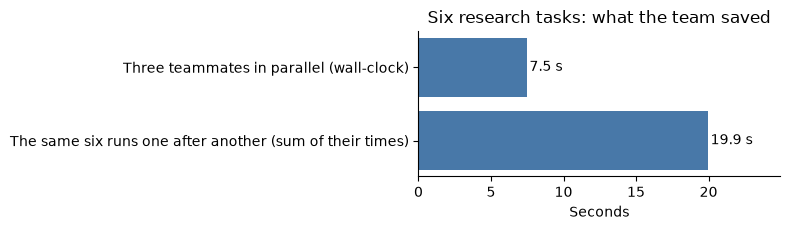

In [11]:
barh(["Three teammates in parallel (wall-clock)", "The same six runs one after another (sum of their times)"],
     [team_seconds, sum_of_worker_seconds], "Six research tasks: what the team saved", "Seconds", fmt="{:.1f} s")

How to read it: the first bar is how long the board took to empty with three teammates working at the same time (7.5 seconds in the run recorded here); the second is what the same six runs would have taken one after another (their individual times added up: 19.9 seconds). The gap is what parallel work buys. Note what it does not buy: the six worker runs happened either way, so the tokens and the cost are the same; only the clock moved.

Read the board log too. The three teammates claimed one task each at the start, and whoever finished first took the next one; each ended up with two tasks, and the six answers plus the lead's briefing cost 0.0706 USD. Nobody assigned anything; the board did. The split of tasks between teammates depends on timing and differs between runs, exactly as it would with real people.

**Claude Code's agent teams do this natively.** The shared task list, the claiming with file locks, the lead that synthesizes, plus the piece our small board lacks: a mailbox, so teammate A can tell teammate B something mid-task without going through the lead. That lateral channel is what sub-agents do not have, and it is also where teams get expensive: every message is more context for its reader. The lab of this session (`lab/04-lab-claude-code-subagents-and-teams.md`) switches teams on and runs a two-teammate task.

## 4. Handoffs: passing the whole conversation

Concrete anchor: a phone call to customer service. First you talk to a general agent; when your problem turns out to be about billing, they transfer you, and the billing specialist can see everything you already said. You do not start over. That is a **handoff**: one agent passes the whole conversation to another and steps back.

OpenAI's guide names two shapes for multi-agent systems. In the **manager pattern**, one agent stays in charge and uses the others as tools; the manager keeps control and the conversation. That is sections 1 and 2. In the **decentralized pattern**, agents **hand off** control to one another; a handoff is a one-way transfer, and the receiving agent continues with the full history (OpenAI, "A practical guide to building agents", Apr 2025). In plain words: delegation says "go find this and report back"; a handoff says "you take it from here".

The package supports it with one argument: `agent.run(task, history=...)` starts the loop with an earlier conversation in front of the new task. Below, a research worker finds two numbers in the README (the passengers and the survivors of the Titanic dataset), and the conversation is handed to a calculator specialist with a `calculate` tool. The specialist never read the README; it inherits the turn that did. To measure what it inherited, we compare the input tokens of its first model call with those of a fresh calculator asked the same arithmetic directly.

In [12]:
import ast
import operator

OPERATORS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul, ast.Div: operator.truediv,
             ast.USub: operator.neg}


@tool(risk="read")
def calculate(expression: str) -> str:
    """Evaluate one arithmetic expression with + - * / and parentheses and return the result.

    expression: for example (891-342)/891
    """
    def walk(node):
        if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
            return node.value
        if isinstance(node, ast.BinOp) and type(node.op) in OPERATORS:
            return OPERATORS[type(node.op)](walk(node.left), walk(node.right))
        if isinstance(node, ast.UnaryOp) and type(node.op) in OPERATORS:
            return OPERATORS[type(node.op)](walk(node.operand))
        raise ValueError(f"unsupported expression: {expression!r}")
    return str(walk(ast.parse(expression, mode="eval").body))


research_run = make_worker("research").run(cases["dataset-size"].task)
print("Research worker:", research_run.answer)
print("messages in that conversation:", len(research_run.messages))

CALC_SYSTEM = "You are a calculator specialist. Use the calculate tool for any arithmetic and answer in one sentence."
specialist = Agent(client, model=WORKER_MODEL, system=CALC_SYSTEM, tools=[calculate], effort="low", max_turns=4, name="calculator")
handed = specialist.run("Using the two numbers found above, what share of the passengers survived? Give a percentage with one decimal.",
                        history=research_run.messages)
print("\nCalculator after the handoff:", handed.answer)
print("messages it holds:", len(handed.messages), "=", len(research_run.messages), "inherited +",
      len(handed.messages) - len(research_run.messages), "new")

fresh = Agent(client, model=WORKER_MODEL, system=CALC_SYSTEM, tools=[calculate], effort="low", max_turns=4, name="fresh-calculator")
fresh_run = fresh.run("What share of 891 is 342? Give a percentage with one decimal.")
print("Fresh calculator:", fresh_run.answer)

handed_first = handed.trace.of_kind("model")[0].input_tokens
fresh_first = fresh_run.trace.of_kind("model")[0].input_tokens
print(f"\nInput tokens of the first model call: after the handoff {handed_first:,} | fresh calculator {fresh_first:,} "
      f"| inherited: {handed_first - fresh_first:,}")
print()
handed.trace.show()
record("Handoff (research, then calculator)", [research_run, handed], answered=1)
record("Fresh calculator (for comparison)", [fresh_run], answered=1)

Research worker: According to the README.md, the Titanic dataset used throughout the course has **891 passengers** and **342 survivors** (with twelve columns), as stated in the "One dataset, nine notebooks" section of `README.md`.
messages in that conversation: 6



Calculator after the handoff: About 38.4% of the passengers survived (342/891).
messages it holds: 10 = 6 inherited + 4 new


Fresh calculator: 342 is approximately 38.4% of 891.

Input tokens of the first model call: after the handoff 7,539 | fresh calculator 522 | inherited: 7,017

turn  kind      name                    in/out tokens      s  detail
   1  model     claude-sonnet-5               7539/52    1.4  stop=tool_use
   1  tool      calculate                                0.0  {'expression': '342/891*100'} -> 38.38383838383838
   2  model     claude-sonnet-5               7603/20    1.0  stop=end_turn About 38.4% of the passengers survived (342/891).
[Handoff (research, then calculator)] 5 model calls, 3 tool calls, 24,469 input tokens, 242 output tokens, 0.0514 USD, 6.2 s
[Fresh calculator (for comparison)] 2 model calls, 1 tool calls, 1,110 input tokens, 71 output tokens, 0.0029 USD, 2.0 s


The calculator answered, and its first model call was larger than a fresh calculator's by exactly the inherited research conversation: the README the worker read, its tool calls, its answer. In the run recorded here that was 7,539 input tokens against 522, so 7,017 inherited tokens in six inherited messages, and the two-run handoff cost 0.0514 USD where the fresh calculator cost 0.0029 USD for the same arithmetic. That is the trade-off of a handoff. The specialist has full context and the user never repeats themselves, but every handoff carries the baggage forward, and a specialist pays for tokens it does not need. Marmelab's 2026 survey found that problems requiring **more than four handoffs almost always failed**. Part of that is coordination, and part is simply that by the fifth handoff the conversation is long, mixed and stale. Section 5 makes that concrete.

## 5. Failure modes

Every architecture above has a way to fail that is specific to it. Three of them are common enough to have names, and a harness engineer builds against all three. Nothing below is staged: we give a real agent a task that invites the failure and let the harness catch it.

### 5.1 The runaway loop

A model that never feels done keeps calling tools. Nothing in the model stops it; only the harness can. The task below is deliberately open-ended: read every file in the repository and summarise each one. A worker will happily keep listing folders and reading files for as long as it is allowed. We run it twice with the two seatbelts of notebook 03: once with `max_turns=4`, once with a token budget, `max_input_tokens=12_000`, which makes the loop ask the API (with `count_tokens`) how big the next call would be and stop before sending it.

In [13]:
OPEN_ENDED = ("Read every file in this repository, folder by folder, and write a one-line summary of each file. "
              "Do not stop until you have read them all.")

turn_capped = make_worker("turn-cap", max_turns=4).run(OPEN_ENDED)
print(f"max_turns=4      -> stopped because {turn_capped.stopped_because!r} after {turn_capped.turns} model calls "
      f"and {len(turn_capped.trace.of_kind('tool'))} tool calls, {turn_capped.cost_usd:.4f} USD")

token_capped = make_worker("token-cap", max_turns=12, max_input_tokens=12_000).run(OPEN_ENDED)
print(f"max_input_tokens -> stopped because {token_capped.stopped_because!r} after {token_capped.turns} model calls "
      f"and {len(token_capped.trace.of_kind('tool'))} tool calls, {token_capped.cost_usd:.4f} USD")
print()
token_capped.trace.show()
per_turn = [event.input_tokens for event in token_capped.trace.of_kind("model")]
print("\ninput tokens the model saw, call by call:", per_turn)
print("growth per call:", [b - a for a, b in zip(per_turn, per_turn[1:])])
record("Runaway prevention (two capped runs)", [turn_capped, token_capped], answered=0)

max_turns=4      -> stopped because 'max_turns' after 4 model calls and 23 tool calls, 0.0279 USD


max_input_tokens -> stopped because 'budget' after 6 model calls and 37 tool calls, 0.0450 USD

turn  kind      name                    in/out tokens      s  detail
   1  model     claude-sonnet-5                738/65    1.3  stop=tool_use
   1  tool      list_files                               0.0  {'folder': '.'} -> .github/ docs/ M1 - Descriptive analytics/ M2 -...
   2  model     claude-sonnet-5               991/432    3.6  stop=tool_use
   2  tool      list_files                               0.0  {'folder': '.github'} -> ISSUE_TEMPLATE/ workflows/ CODEOWNERS dependabo...
   2  tool      list_files                               0.0  {'folder': 'docs'} -> assets/ data/ .nojekyll app.js index.html style...
   2  tool      list_files                               0.0  {'folder': 'M1 - Descriptive analytics'} -> 01-data-cleaning.ipynb 02-descriptive-stati...
   2  tool      list_files                               0.0  {'folder': 'M2 - Machine Learning'} -> 01-data-prep-and-feature

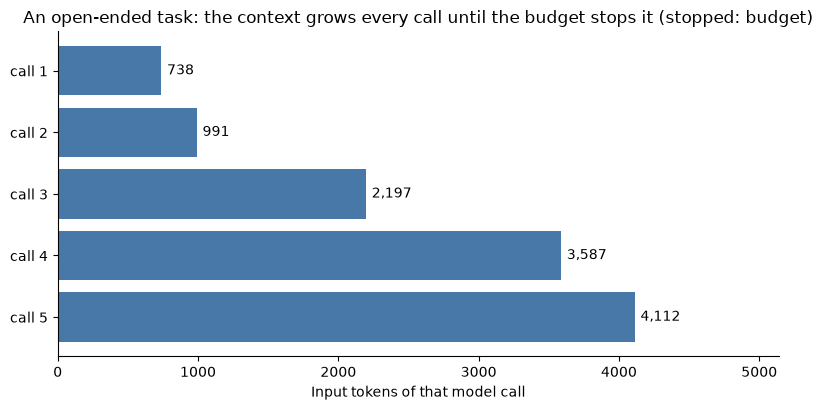

In [14]:
barh([f"call {i}" for i in range(1, len(per_turn) + 1)], per_turn,
     f"An open-ended task: the context grows every call until the budget stops it (stopped: {token_capped.stopped_because})",
     "Input tokens of that model call")

How to read it: one bar per model call, in order; the length is the number of input tokens the API billed for that call, which is the size of the context the model was sent. Each call adds the previous tool results to the context, so the bars grow, and the total bill grows faster than the number of calls. In the run recorded here the five calls saw 738, 991, 2,197, 3,587 and 4,112 tokens; then the worker asked for a whole batch of files at once, and `count_tokens` measured the next call at 17,810 tokens, above the 12,000 budget. The `budget` line at the end of the trace is the harness refusing to send that call. (The run reports `turns=6` because the sixth turn started and was stopped before its model call; count the `model` lines in the trace when you want the number of calls.) The `max_turns=4` run stopped after four calls and 23 tool calls. Neither run produced a summary, and together they cost 0.0729 USD. Without the seatbelt the run would have continued until the context window overflowed or the bill did. A trace is how you notice a runaway before the invoice does.

### 5.2 Context pollution

Section 1 gave the solo agent a three-part question in one context. Here is what it did with it, part by part. **Context pollution** is material from several tasks in one window, where the strongest signal wins and the rest is silently lost: a part of the question answered thinly, a wrong file carried into a later step, or a part simply forgotten. Nothing fails loudly, which is why you grade the answer instead of reading it.

In [15]:
print("Solo agent, part by part:")
for part, ok in solo_parts.items():
    print(f"   {'answered' if ok else 'missing '}  {part}")
print(f"Parts answered: {sum(solo_parts.values())} of {len(PARTS)} | model calls: {solo_run.turns} | "
      f"tool calls: {len(solo_run.trace.of_kind('tool'))} | final context: {solo_context:,} tokens")
print("Files it read, in order:", [e.detail.split("->")[0].strip() for e in solo_run.trace.of_kind("tool") if e.name == "read_file"])

print("\nLead + workers, part by part:")
for part, ok in lead_parts.items():
    print(f"   {'answered' if ok else 'missing '}  {part}")
print(f"Parts answered: {sum(lead_parts.values())} of {len(PARTS)} | lead's final context: {lead_context:,} tokens")

Solo agent, part by part:
   answered  part 1: the workflow (Python 3.12, actions v7)
   answered  part 2: the M3-only packages
   answered  part 3: the model metrics
Parts answered: 3 of 3 | model calls: 3 | tool calls: 5 | final context: 3,985 tokens
Files it read, in order: ["{'path': '.github/workflows/notebooks...", "{'path': 'requirements.txt'}", "{'path': 'docs/data/model.json'}"]

Lead + workers, part by part:
   answered  part 1: the workflow (Python 3.12, actions v7)
   answered  part 2: the M3-only packages
   answered  part 3: the model metrics
Parts answered: 3 of 3 | lead's final context: 1,527 tokens


In the run recorded here the solo agent was not polluted: it answered all three parts, in three model calls, reading exactly the three files it needed, and it did so for less money (0.0402 against 0.0444 USD) and in a third of the time, because it made no detours. That is an honest result and an important one: on three facts the strong model coped, so for this question the solo agent was the right tool, which is what "scale effort to the complexity of the query" means. The comparison to make is context size against coverage. The solo agent must hold every file it opened until the end (3,985 tokens); the lead holds three reports (1,527 tokens). On ten facts, or on files ten times longer, the solo agent's context would keep growing and you would not know which fact it dropped without a grader. The sub-agent design is the cure: one part per context, so every part gets a clean search. The same failure appears in long single-agent sessions when a user changes topic and the old material keeps steering; compaction (notebook 02) and note-taking are the single-agent remedies.

### 5.3 Cost multiplication

Every agent that reads the same material pays for it again. Here is the bill for the architectures in this notebook, from the ledger `record()` kept, using the real `usage` of every run.

In [16]:
bill = pd.DataFrame(LEDGER).set_index("architecture")
answered = bill["questions answered"].astype("float")
bill["cost per answered question"] = (bill["cost_usd"] / answered.where(answered > 0)).round(4)
bill["multiple of solo"] = (bill["cost_usd"] / bill.loc["Solo agent", "cost_usd"]).round(1)
display(bill[["runs", "model calls", "tool calls", "input tokens", "output tokens", "cost_usd",
              "questions answered", "cost per answered question", "multiple of solo"]])

,runs,model calls,tool calls,input tokens,output tokens,cost_usd,questions answered,cost per answered question,multiple of solo
architecture,,,,,,,,,
Lead + workers,4,9,7,10081,995,0.0444,3,0.0148,1.1
Solo agent,1,3,5,5702,469,0.0402,3,0.0134,1.0
Orchestrator-workers,6,12,6,12519,1074,0.0415,3,0.0138,1.0
Team of 3 + lead,7,17,10,24611,1322,0.0706,6,0.0118,1.8
"Handoff (research, then calculator)",2,5,3,24469,242,0.0514,1,0.0514,1.3
Fresh calculator (for comparison),1,2,1,1110,71,0.0029,1,0.0029,0.1
Runaway prevention (two capped runs),2,10,60,18958,3495,0.0729,0,NaN,1.8


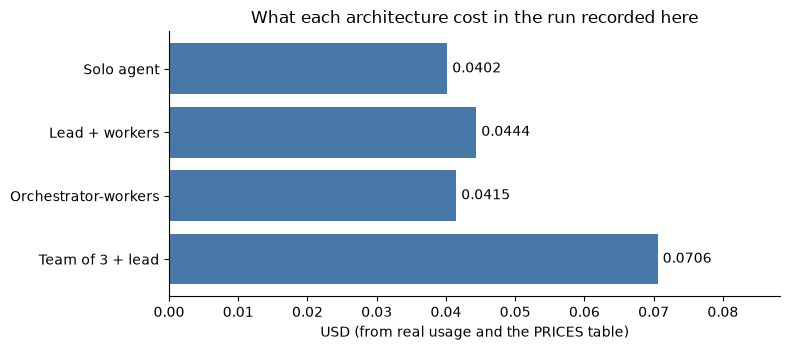

In [17]:
architectures = ["Solo agent", "Lead + workers", "Orchestrator-workers", "Team of 3 + lead"]
barh(architectures, [bill.loc[a, "cost_usd"] for a in architectures],
     "What each architecture cost in the run recorded here", "USD (from real usage and the PRICES table)", fmt="{:.4f}")

How to read it: one bar per architecture, the cost of every model call it made, workers included. Read it together with the "questions answered" column of the table: the team answered six questions, the others answered the same three-part question. The cost per answered question is the number to compare, and in the run recorded here it was roughly the same everywhere, between 0.0118 (team) and 0.0148 USD (lead), because every answer needs its own listing, reading and writing. The team cost 1.8 times the solo agent for twice the questions. The one outlier is the handoff: 0.0514 USD for a single answer, because two calls on the specialist carried 7,017 inherited tokens each. What multiplies is the number of contexts doing that reading, plus the coordination on top, and coordination on the strong model is the expensive part.

Anthropic's research system used about fifteen times the tokens of a chat for its 90.2 percent gain; that is a good trade for a hard research question and a terrible one for a simple lookup, which is what "scale effort to query complexity" means in practice. Two more numbers from Marmelab's 2026 survey belong here. Adding a **reviewer agent lowered the success rate by 8 percent** in one setup: the reviewer introduced disagreements and rework that a single well-verified agent did not need. And problems requiring **more than four handoffs almost always failed**. More agents means more coordination, and coordination is where multi-agent systems break. Start with the simplest thing that works, and add agents only when an eval shows they help.

## 6. The discipline

Everything in this module reduces to one habit: **do not ask the model to behave; build the thing that makes behaving the only option.** OpenAI's phrase for it is deterministic scaffolding around probabilistic model steps (Lopopolo, 11 Feb 2026). Here is the checklist harness engineers work from, with the survey numbers that show why each item exists (Marmelab, "The State of AI Harness Engineering 2026", 24 Sep 2026).

**1. Instruction files.** Standing rules live in a file the agent reads on every task (`CLAUDE.md`, `AGENTS.md`). Write them by hand and keep them short: human-written instruction files improved success by about 4 percent, while machine-generated ones did worse than no file at all. When everything is marked important, nothing is. The lab's `CLAUDE.md` is one; the system prompts of this notebook are the same idea for one agent.

**2. Executable guards.** Every rule that matters becomes a hook, a linter or a test, not a sentence. Of the security rules written into instruction files, **only 4.4 percent were backed by a real control**. The `before_tool` hook that refuses `.env`, the `validate_answer` hook that demands sources, the `danger` risk label that keeps `run_shell` off by default (notebook 03), and the `PreToolUse` hook of the lab are what a real control looks like; OpenAI enforced its repository rules with custom linters and structural tests in CI.

**3. Evals in CI.** A suite of tasks with graders, including trap cases, runs on every change to a prompt, a tool or a model. **60 percent of harnesses ship without tests or evals**; the fourteen-case suite of notebook 03 costs cents to run, and the `harness.yml` workflow runs it whenever the repository holds a key.

**4. Observability.** Every run leaves a trace: model calls, tool calls, denials, tokens, time. Every number in these four notebooks came out of `result.trace` and `result.usage`, including the ones that showed the runaway loop and the inherited handoff tokens above. Without traces, cost and failure are opinions.

**5. Permission design.** Tools carry risk levels; dangerous ones are denied by default and run in a sandbox when allowed; human approval is reserved for the rare decision. **93 percent of permission prompts get approved**, so an approval gate that fires often protects nothing.

**6. Effort that matches the task.** One agent for a lookup, sub-agents for a broad question, a team for a pile of independent work, and a cap on handoffs. More than four handoffs almost always failed; a reviewer agent cost 8 points. Delegation is taught, not assumed.

### The future

The discipline is young: Marmelab counted **21,500 "agent harness" repositories created in 2026**, with a median age of 8.7 months, and a source-code study of eleven coding agents found that the field runs on hand-rolled asynchronous loops and deterministic retrieval rather than general frameworks (Barbaste and colleagues, arXiv 2609.00006, Jul 2026). Three things seem settled. The **repository is becoming the system of record**: OpenAI's team shipped about one million lines of production code in five months with zero lines written by hand, because design documents, decision records and execution plans lived in the repo where the agent could read them. **Skills are becoming a standard**: the folder-with-a-SKILL.md format was published as an open standard in December 2025 and more than forty platforms support it. And **the harness is where the leverage is**: the same model scored 45.9 percent on SWE-bench Pro under one scaffold and 55.4 under another (arXiv 2609.11987, Sep 2026). The model is the engine. The harness is the rest of the car, and the car is what people drive.

### What you built: the eight pieces across four notebooks

| Piece of the harness | In plain words | What you built |
|---|---|---|
| 1. Model | The engine: context in, next message out | Notebook 01: `client.messages.create` on the raw SDK, and what one call costs. Notebook 02: the same question to three Claude models. |
| 2. Context | Everything the model sees in one call, a finite budget | Notebook 02: `count_tokens`, a growing session, compaction done by a model, notes outside the window. Notebook 04: sub-agents that keep the lead's context small. |
| 3. Tools | Functions the model asks for by name; the harness runs them | Notebook 01: `list_files` and `read_file` as hand-written JSON schemas in a forty-line loop. Notebook 02: the vague-description experiment, errors as `tool_result`, gating. |
| 4. Skills | Folders of instructions, loaded on demand | Notebook 02: a real `SKILL.md`, the tokens of the catalog line against the body, a `load_skill` tool. Lab 2: Claude Code loading it for you. |
| 5. The loop | Gather context, take action, verify work, repeat, with stop conditions | Notebook 01: the loop by hand, then `tool_runner`. Notebook 03: `Agent.run()` with `done`, `max_turns`, `budget`, `refusal`, `max_tokens`. Notebook 04: the open-ended task that the budget stopped. |
| 6. Guardrails and permissions | Checks that run outside the model | Notebook 03: `before_tool`, `validate_answer`, risk levels and `deny_risk`. Notebook 04: a cap on delegation (exercise 1). Lab 4: a `PreToolUse` hook and `deny` rules. |
| 7. Orchestration | Workflows when the path is known, agents when it is not; sub-agents, teams, handoffs | Notebook 03: the five workflow patterns. Notebook 04: a lead with a `delegate` tool, a team with a board, a handoff to a specialist. Lab 4: subagents and agent teams in Claude Code. |
| 8. Evals and observability | A task, a grader, an outcome; a trace of every step | Notebook 03: fourteen cases over three configurations, the CI workflow, the bill. Notebook 04: token accounting per architecture and a judge (exercise 3). |

## 7. Key takeaways

- A **sub-agent** is a fresh agent with a clean context, one focused task and a short report back. Built as a tool whose implementation is another agent, it lets the lead answer a whole compound question while carrying only the reports (1,527 tokens against 3,985 for the solo agent in the run recorded here). On three facts the solo agent kept up and cost less; isolation pays when the question or the files outgrow one context.
- **Orchestrator-workers** is a workflow: code decides the shape, two coordination calls, workers in parallel. **Sub-agents as tools** is an agent: the model decides when to delegate, pays for each decision on the strong model, and runs its delegations in order. Same reading, different locus of control.
- **Agent teams** are flat: a shared board, direct messages, a lead that synthesizes. Parallel teammates move the clock (7.5 seconds against 19.9 in the run recorded here), not the token count. **Sub-agents** are hierarchical: no lateral talk, results flow up.
- A **handoff** transfers the whole conversation; delegation asks for a report. The specialist's first call carries every inherited token, and more than four handoffs almost always failed.
- The three failure modes are the **runaway loop** (only `max_turns` and a token budget stop it), **context pollution** (grade the answer, do not read it) and **cost multiplication** (every context that reads pays; coordination on the strong model is the expensive part).
- The discipline is a checklist: instruction files, executable guards, evals in CI, observability, permission design, effort matched to the task. Do not ask the model to behave; build the thing that makes behaving the only option.

## 8. Practice exercises

Try these before looking at the solutions. Each one costs a few cents to run.

**Exercise 1 - Cap the delegations.** Write a `before_tool` hook that allows at most two `delegate` calls per run and denies the rest with a clear reason. Run a new lead on `COMPOUND` with that hook, and tell the lead about the cap in its system prompt. How many workers started, and what did the lead do about the third part of the question?

**Exercise 2 - A fourth teammate.** Run `run_team(TASKS, teammates=4)`. Compare the wall-clock seconds and the cost with the three-teammate run. What changes, and what does not? Explain why in one sentence.

**Exercise 3 - A stricter judge.** `parts_answered()` grades by looking for strings. Build a judge `Agent` on the worker model with a structured output (`complete`, `missing_parts`, `files_named`) that reads the three-part question and an answer and says which parts are answered and how many files the answer names. Run it on the lead's answer and on the solo agent's answer. Do the judge and the string check agree?

## 9. Solutions

### Solution 1 - Cap the delegations

The hook counts `delegate` requests and denies the third with a reason the model can read. Because the denial arrives as an `is_error` tool result, a real lead does not crash: it reads the reason and decides what to do with the part it could not delegate. In the run recorded here the hook never had to fire: told about the cap in its system prompt, the lead planned two delegations, the second covering two files, answered all three parts, and cost slightly less than the uncapped lead (0.0424 against 0.0444 USD). The hook is the seatbelt; the sentence in the system prompt is what let the model plan around it. Run it again and the model may split differently; then the `denied` line appears in the trace and the answer says what is missing.

In [18]:
delegate_calls = {"count": 0}


def cap_delegations(request, candidate):
    if request.name == "delegate":
        delegate_calls["count"] += 1
        if delegate_calls["count"] > 2:
            return "Denied: the delegation budget of 2 workers is spent. Combine what you have and say what is missing."
    return None


before = len(workers)
capped_lead = Agent(client, model=MAIN_MODEL, tools=[delegate], effort="medium", max_turns=6, name="capped-lead",
                    hooks=Hooks(before_tool=[cap_delegations]),
                    system=LEAD_SYSTEM + " You may delegate at most twice per question; plan the split accordingly.")
capped_run = capped_lead.run(COMPOUND)
capped_workers = workers[before:]

print(capped_run.answer)
print()
capped_run.trace.show()
capped_parts = parts_answered(capped_run.answer)
print(f"\nworkers started: {len(capped_workers)} | denied delegate calls: {capped_run.trace.summary()['denied']} | "
      f"parts answered: {sum(capped_parts.values())} of {len(PARTS)}")
record("Capped lead (exercise 1)", [capped_run] + [r for _, r in capped_workers], answered=sum(capped_parts.values()))

**1) "Execute notebooks" workflow** — `.github/workflows/notebooks.yml`
- Installs **Python 3.12**
- Uses **actions/checkout@v7** and **actions/setup-python@v7** (in both the `execute` and `module-5` jobs)

**2) Packages only needed for M3 notebooks 2 and 3** — `requirements.txt`
- Under the comment `# Prediction APIs (only needed for M3 notebooks 2 and 3)`: **`fastapi`, `uvicorn`, `httpx`, `requests`**

**3) Reported model metrics** — `docs/data/model.json`
- `"test_accuracy": 0.838`
- `"test_f1": 0.779`
- `"test_auc": 0.878`

turn  kind      name                    in/out tokens      s  detail
   1  model     claude-opus-5                 699/307    4.6  stop=tool_use I'll split this into three focused sub-questions and dele...
   1  tool      delegate                                 3.8  {'task': "In this code repository, fi... -> The workflow "Execute notebooks" is defined...
   1  tool      delegate                                 5.0  {'task': 'In this code repository, op... -> I

### Solution 2 - A fourth teammate

The tokens are set by the work, not by the headcount: six tasks need six research runs whether three or four teammates do them. What changes is the clock, and only while there are more tasks than teammates. With six tasks, three teammates need two rounds and so do four (two of them take a second task while the other two wait), so there is nothing to save: in the run recorded here the four-teammate board took 7.9 seconds against 7.5, and cost 0.0715 against 0.0706 USD, the same within noise.

In [19]:
board4, team4_runs, team4_lead_run, team4_seconds = run_team(TASKS, teammates=4)
print("Tasks per teammate:", {name: sum(1 for i in board4.items if i["owner"] == name)
                              for name in sorted({i["owner"] for i in board4.items})})
print(f"3 teammates: {team_seconds:.1f} s wall-clock, {sum(r.cost_usd for r in team_runs) + team_lead_run.cost_usd:.4f} USD")
print(f"4 teammates: {team4_seconds:.1f} s wall-clock, {sum(r.cost_usd for r in team4_runs) + team4_lead_run.cost_usd:.4f} USD")
print("tasks done:", len(board4.done()), "of", len(TASKS))
record("Team of 4 + lead (exercise 2)", team4_runs + [team4_lead_run], answered=len(board4.done()))

Tasks per teammate: {'teammate-1': 1, 'teammate-2': 2, 'teammate-3': 2, 'teammate-4': 1}
3 teammates: 7.5 s wall-clock, 0.0706 USD
4 teammates: 7.9 s wall-clock, 0.0715 USD
tasks done: 6 of 6
[Team of 4 + lead (exercise 2)] 17 model calls, 10 tool calls, 24,624 input tokens, 1,365 output tokens, 0.0715 USD, 26.2 s


### Solution 3 - A stricter judge

The judge is an agent with no tools and a JSON schema for its answer, the evaluator of notebook 03 in miniature. It reads the question and an answer, and returns fields a program can check. In the run recorded here the judge and the string check agreed: both answers complete, three files named in each. Where they disagree, read both: a judge can spot a fact stated in different words, and it can also be fooled by a confident answer, which is why the eval suite of notebook 03 kept `source_file` checks that no judge can talk its way around.

In [20]:
JUDGE_SCHEMA = {
    "type": "object",
    "properties": {
        "complete": {"type": "boolean", "description": "true only when every part of the question is answered with a concrete value"},
        "missing_parts": {"type": "array", "items": {"type": "string"}, "description": "the parts not answered, in a few words each"},
        "files_named": {"type": "integer", "description": "how many distinct repository file paths the answer names"},
    },
    "required": ["complete", "missing_parts", "files_named"],
}
judge = Agent(client, model=WORKER_MODEL, effort="low", output_schema=JUDGE_SCHEMA, name="judge",
              system="You grade answers to a multi-part question. Judge only what the answer states; do not check facts "
                     "against your own knowledge. Return only the JSON object.")

verdicts = {}
for label, answer, parts in [("lead + workers", lead_run.answer, lead_parts), ("solo agent", solo_run.answer, solo_parts)]:
    verdict = judge.run(f"Question:\n{COMPOUND}\n\nAnswer to grade:\n{answer}")
    verdicts[label] = verdict
    print(f"{label}: judge says complete={verdict.parsed['complete']}, files named={verdict.parsed['files_named']}, "
          f"missing={verdict.parsed['missing_parts']} | string check: {sum(parts.values())} of {len(PARTS)} parts")
record("Judge (exercise 3)", list(verdicts.values()), answered=None)

lead + workers: judge says complete=True, files named=3, missing=[] | string check: 3 of 3 parts


solo agent: judge says complete=True, files named=3, missing=[] | string check: 3 of 3 parts
[Judge (exercise 3)] 2 model calls, 0 tool calls, 1,480 input tokens, 50 output tokens, 0.0035 USD, 4.6 s


## 10. The bill

Every run of this notebook, from the ledger. Prices come from `harness.client.PRICES`; the token counts come from the `usage` object of every API response.

In [21]:
final_bill = pd.DataFrame(LEDGER).set_index("architecture")[["runs", "model calls", "input tokens", "output tokens", "cost_usd"]]
display(final_bill)
print(f"Total cost of this notebook in the run recorded here: {final_bill['cost_usd'].sum():.4f} USD "
      f"({final_bill['input tokens'].sum():,} input tokens, {final_bill['output tokens'].sum():,} output tokens, "
      f"{int(final_bill['model calls'].sum())} model calls)")

,runs,model calls,input tokens,output tokens,cost_usd
architecture,,,,,
Lead + workers,4,9,10081,995,0.0444
Solo agent,1,3,5702,469,0.0402
Orchestrator-workers,6,12,12519,1074,0.0415
Team of 3 + lead,7,17,24611,1322,0.0706
"Handoff (research, then calculator)",2,5,24469,242,0.0514
Fresh calculator (for comparison),1,2,1110,71,0.0029
Runaway prevention (two capped runs),2,10,18958,3495,0.0729
Capped lead (exercise 1),3,7,8775,1034,0.0424
Team of 4 + lead (exercise 2),7,17,24624,1365,0.0715


Total cost of this notebook in the run recorded here: 0.4413 USD (132,329 input tokens, 10,117 output tokens, 84 model calls)
